# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Najwa Salsabila
- **Email:** cdcc001d6x1036@student.devacademy.id
- **ID Dicoding:** CDCC001D6X1036

## Menentukan Pertanyaan Bisnis

Dalam proyek ini, kita menganalisis **Bike Sharing Dataset**, data peminjaman sepeda dari layanan Capital Bikeshare di Washington D.C., USA, tahun 2011-2012. Dataset mencakup informasi cuaca, musim, hari, dan jam.

**Pertanyaan Bisnis:**
- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca dan musim terhadap total jumlah peminjaman sepeda harian? Kondisi dan musim apa yang menghasilkan peminjaman tertinggi?
- **Pertanyaan 2:** Pada jam berapa terjadi puncak peminjaman sepeda dalam sehari, dan bagaimana perbedaan pola penggunaan antara hari kerja (*workingday*) dan hari libur?
- **Pertanyaan 3 (Analisis Lanjutan):** Bagaimana karakteristik segmen hari berdasarkan tingkat penggunaan (*Low*, *Medium*, *High Usage*) yang diperoleh melalui teknik **clustering manual (binning)**?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Pengaturan tampilan global
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 10,
})
COLOR_PRIMARY = '#2196F3'

print('Libraries berhasil diimport.')
print(f'pandas    : {pd.__version__}')
print(f'numpy     : {np.__version__}')
print(f'matplotlib: {plt.matplotlib.__version__}')
print(f'seaborn   : {sns.__version__}')

Libraries berhasil diimport.
pandas    : 2.2.2
numpy     : 2.0.2
matplotlib: 3.10.0
seaborn   : 0.13.2


---
## Data Wrangling

### Gathering Data

Memuat dua dataset dari Bike Sharing:
- **`day.csv`** - data agregat harian (731 baris, 16 kolom)
- **`hour.csv`** - data per jam (17.379 baris, 17 kolom)

Kedua file merupakan data penggunaan Capital Bikeshare di Washington D.C., USA, tahun 2011–2012.

In [ ]:
day_df  = pd.read_csv('/content/day.csv')
hour_df = pd.read_csv('/content/hour.csv')

print('day.csv')
print(f'Shape : {day_df.shape}')
print(day_df.head())

print('\nhour.csv')
print(f'Shape : {hour_df.shape}')
print(hour_df.head())

day.csv
Shape : (731, 16)
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  


**Insight : Gathering Data:**
- Dataset `day.csv` memiliki **731 baris** dan **16 kolom**, mencakup data harian dari 1 Januari 2011 hingga 31 Desember 2012.
- Dataset `hour.csv` memiliki **17.379 baris** dan **17 kolom** (kolom tambahan `hr` untuk jam).
- Kolom target utama adalah `cnt` (total peminjaman = `casual` + `registered`).
- Kolom seperti `season`, `weathersit`, `weekday` dikodekan sebagai integer, perlu konversi ke label kategoris yang bermakna.

### Assessing Data

Periksa kualitas data: missing values, duplikasi, tipe data, dan statistik deskriptif.

In [ ]:
def assess_dataframe(df, name):
    print(f"{'='*50}")
    print(f" Asesmen: {name}")
    print(f"{'='*50}")
    print('\n[INFO] Tipe Data:')
    print(df.dtypes)
    mv = df.isnull().sum()
    print('\n[INFO] Missing Values:')
    print(mv[mv > 0] if mv.sum() > 0 else '  Tidak ada missing values.')
    print(f'\n[INFO] Duplikasi: {df.duplicated().sum()} baris')
    print('\n[INFO] Statistik Deskriptif:')
    print(df.describe().T.round(2))

assess_dataframe(day_df,  'day.csv')
assess_dataframe(hour_df, 'hour.csv')

 Asesmen: day.csv

[INFO] Tipe Data:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

[INFO] Missing Values:
  Tidak ada missing values.

[INFO] Duplikasi: 0 baris

[INFO] Statistik Deskriptif:
            count     mean      std    min      25%      50%      75%      max
instant     731.0   366.00   211.17   1.00   183.50   366.00   548.50   731.00
season      731.0     2.50     1.11   1.00     2.00     3.00     3.00     4.00
yr          731.0     0.50     0.50   0.00     0.00     1.00     1.00     1.00
mnth        731.0     6.52     3.45   1.00     4.00     7.00    10.00    12.00
holiday     731.0     0.03     0.17   0.00     0.00     0.00     0.00     1.00
weekday     73

**Insight - Assessing Data:**
- **Tidak ada missing values** pada kedua dataset.
- **Tidak ada baris duplikat.**
- Kolom `dteday` bertipe `object` → perlu dikonversi ke `datetime`.
- Kolom `season`, `weathersit`, `weekday`, `yr` dikodekan sebagai integer, perlu label kategoris.
- Fitur `temp`, `hum`, `windspeed` sudah ternormalisasi ke rentang [0, 1] → tidak ada outlier ekstrem.

### Cleaning Data

Langkah cleaning yang dilakukan:
1. Konversi kolom `dteday` dari `object` ke `datetime`.
2. Tambah kolom bantu `year` dan `month`.
3. Buat kolom label kategoris untuk `season`, `weathersit`, `weekday`, dan `yr`.

In [ ]:
season_map  = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
weather_map = {1:'Clear',  2:'Mist',   3:'Light Snow/Rain', 4:'Heavy Rain'}
weekday_map = {0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'}
yr_map      = {0:'2011', 1:'2012'}

def clean_dataframe(df):
    df = df.copy()
    df['dteday']        = pd.to_datetime(df['dteday'])
    df['year']          = df['dteday'].dt.year
    df['month']         = df['dteday'].dt.month
    df['season_label']  = df['season'].map(season_map).astype('category')
    df['weather_label'] = df['weathersit'].map(weather_map).astype('category')
    df['weekday_label'] = df['weekday'].map(weekday_map).astype('category')
    df['yr_label']      = df['yr'].map(yr_map).astype('category')
    return df

day_df  = clean_dataframe(day_df)
hour_df = clean_dataframe(hour_df)

new_cols = ['year','month','season_label','weather_label','weekday_label','yr_label']
print('Cleaning selesai.')
print(f'day_df  shape : {day_df.shape}')
print(f'hour_df shape : {hour_df.shape}')
print('\nKolom baru (5 baris pertama):')
print(day_df[new_cols].head())

Cleaning selesai.
day_df  shape : (731, 22)
hour_df shape : (17379, 23)

Kolom baru (5 baris pertama):
   year  month season_label weather_label weekday_label yr_label
0  2011      1       Spring          Mist           Sat     2011
1  2011      1       Spring          Mist           Sun     2011
2  2011      1       Spring         Clear           Mon     2011
3  2011      1       Spring         Clear           Tue     2011
4  2011      1       Spring         Clear           Wed     2011


**Insight - Cleaning Data:**
- Kolom `dteday` berhasil dikonversi ke `datetime64`.
- Kolom label baru berhasil ditambahkan untuk memudahkan visualisasi dan analisis.
- Tidak ada baris yang dihapus — data tetap lengkap **731 baris** (day) dan **17.379 baris** (hour).
- Dataset siap untuk EDA.

---
## Exploratory Data Analysis (EDA)

### Explore Distribusi Total Peminjaman Harian

In [ ]:
print('Statistik Deskriptif: cnt (day_df)')
stats = day_df['cnt'].describe()
print(stats)
print(f'\nSkewness : {day_df["cnt"].skew():.3f}')
print(f'Kurtosis : {day_df["cnt"].kurt():.3f}')

Statistik Deskriptif: cnt (day_df)
count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: cnt, dtype: float64

Skewness : -0.047
Kurtosis : -0.812


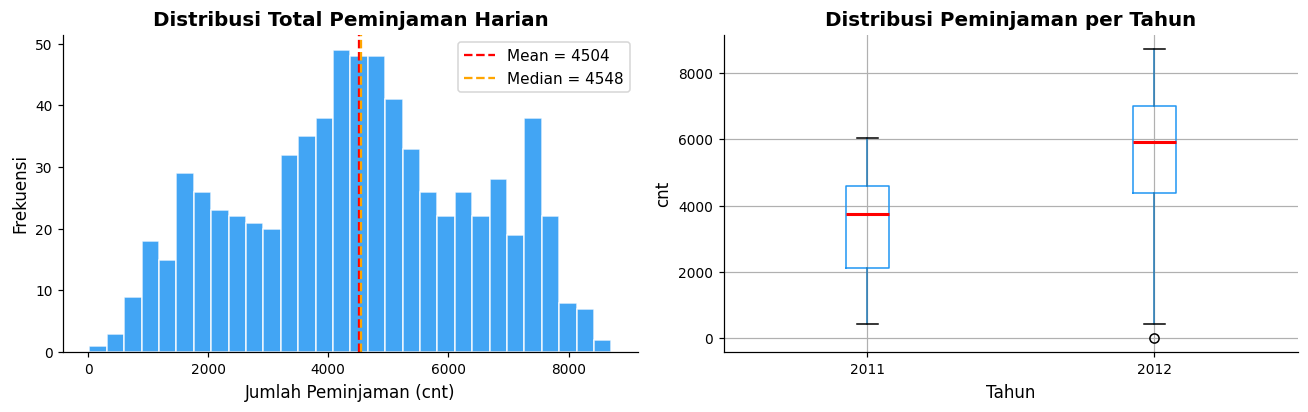

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(day_df['cnt'], bins=30, color=COLOR_PRIMARY, edgecolor='white', alpha=0.85)
axes[0].axvline(day_df['cnt'].mean(),   color='red',    linestyle='--', lw=1.5,
                label=f"Mean = {day_df['cnt'].mean():.0f}")
axes[0].axvline(day_df['cnt'].median(), color='orange', linestyle='--', lw=1.5,
                label=f"Median = {day_df['cnt'].median():.0f}")
axes[0].set_title('Distribusi Total Peminjaman Harian')
axes[0].set_xlabel('Jumlah Peminjaman (cnt)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

day_df.boxplot(column='cnt', by='yr_label', ax=axes[1],
               boxprops=dict(color=COLOR_PRIMARY),
               medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Distribusi Peminjaman per Tahun')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('cnt')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Insight:**
- Distribusi `cnt` harian **sedikit left-skewed**, lebih banyak hari dengan peminjaman tinggi.
- Terdapat peningkatan signifikan dari 2011 ke 2012: **median 2012 (~4.500) jauh lebih tinggi** dari 2011 (~3.000), menunjukkan pertumbuhan adopsi layanan.
- Beberapa outlier bawah di 2011 kemungkinan adalah hari cuaca ekstrem di awal tahun.

### Explore Pengaruh Cuaca dan Musim terhadap Peminjaman

In [ ]:
weather_stats = day_df.groupby('weather_label', observed=True)['cnt']\
                .agg(['mean','median','count']).round(1)
weather_stats.columns = ['Rata-rata','Median','Jumlah Hari']

season_stats = day_df.groupby('season_label', observed=True)['cnt']\
               .agg(['mean','median','count']).round(1)
season_stats.columns = ['Rata-rata','Median','Jumlah Hari']

print('Statistik per Kondisi Cuaca')
print(weather_stats.sort_values('Rata-rata', ascending=False))
print('\nStatistik per Musim')
print(season_stats.sort_values('Rata-rata', ascending=False))

Statistik per Kondisi Cuaca
                 Rata-rata  Median  Jumlah Hari
weather_label                                  
Clear               4876.8  4844.0          463
Mist                4035.9  4040.0          247
Light Snow/Rain     1803.3  1817.0           21

Statistik per Musim
              Rata-rata  Median  Jumlah Hari
season_label                                
Fall             5644.3  5353.5          188
Summer           4992.3  4941.5          184
Winter           4728.2  4634.5          178
Spring           2604.1  2209.0          181


**Insight:**
- Cuaca **Clear** menghasilkan rata-rata peminjaman tertinggi; **Light Snow/Rain** terendah.
- Musim **Fall** adalah musim dengan rata-rata peminjaman tertinggi, diikuti Summer, Winter, dan Spring sebagai yang terendah.

### Explore Pola Peminjaman per Jam

In [ ]:
hourly_stats   = hour_df.groupby('hr')[['cnt','casual','registered']].mean().round(1)
hourly_workday = hour_df[hour_df['workingday']==1].groupby('hr')[['casual','registered','cnt']].mean()
hourly_weekend = hour_df[hour_df['workingday']==0].groupby('hr')[['casual','registered','cnt']].mean()

print('Rata-rata Peminjaman per Jam')
print(hourly_stats)
print(f'\nJam tertinggi  : {hourly_stats["cnt"].idxmax()}:00 ({hourly_stats["cnt"].max():.1f})')
print(f'Jam terendah   : {hourly_stats["cnt"].idxmin()}:00 ({hourly_stats["cnt"].min():.1f})')
print(f'\nHari Kerja  — puncak jam : {hourly_workday["cnt"].idxmax()}:00 ({hourly_workday["cnt"].max():.1f})')
print(f'Hari Libur  — puncak jam : {hourly_weekend["cnt"].idxmax()}:00 ({hourly_weekend["cnt"].max():.1f})')

Rata-rata Peminjaman per Jam
      cnt  casual  registered
hr                           
0    53.9    10.2        43.7
1    33.4     6.5        26.9
2    22.9     4.8        18.1
3    11.7     2.7         9.0
4     6.4     1.3         5.1
5    19.9     1.4        18.5
6    76.0     4.2        71.9
7   212.1    11.1       201.0
8   359.0    21.7       337.3
9   219.3    30.9       188.4
10  173.7    46.5       127.2
11  208.1    59.5       148.6
12  253.3    68.3       185.0
13  253.7    72.3       181.4
14  240.9    75.6       165.4
15  251.2    74.9       176.3
16  312.0    73.7       238.2
17  461.5    74.3       387.2
18  425.5    61.1       364.4
19  311.5    48.8       262.8
20  226.0    36.2       189.8
21  172.3    28.3       144.1
22  131.3    22.3       109.1
23   87.8    15.2        72.6

Jam tertinggi  : 17:00 (461.5)
Jam terendah   : 4:00 (6.4)

Hari Kerja  — puncak jam : 17:00 (525.3)
Hari Libur  — puncak jam : 13:00 (372.7)


**Insight:**
- Hari kerja → **dua puncak**: pukul 08:00 (berangkat) dan 17:00–18:00 (pulang kerja).
- Hari libur → **satu puncak**: pukul 11:00–14:00 (rekreasi siang).
- Pengguna **registered** dominan di hari kerja; pengguna **casual** lebih aktif di weekend.

---
## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca dan musim terhadap total peminjaman sepeda harian?

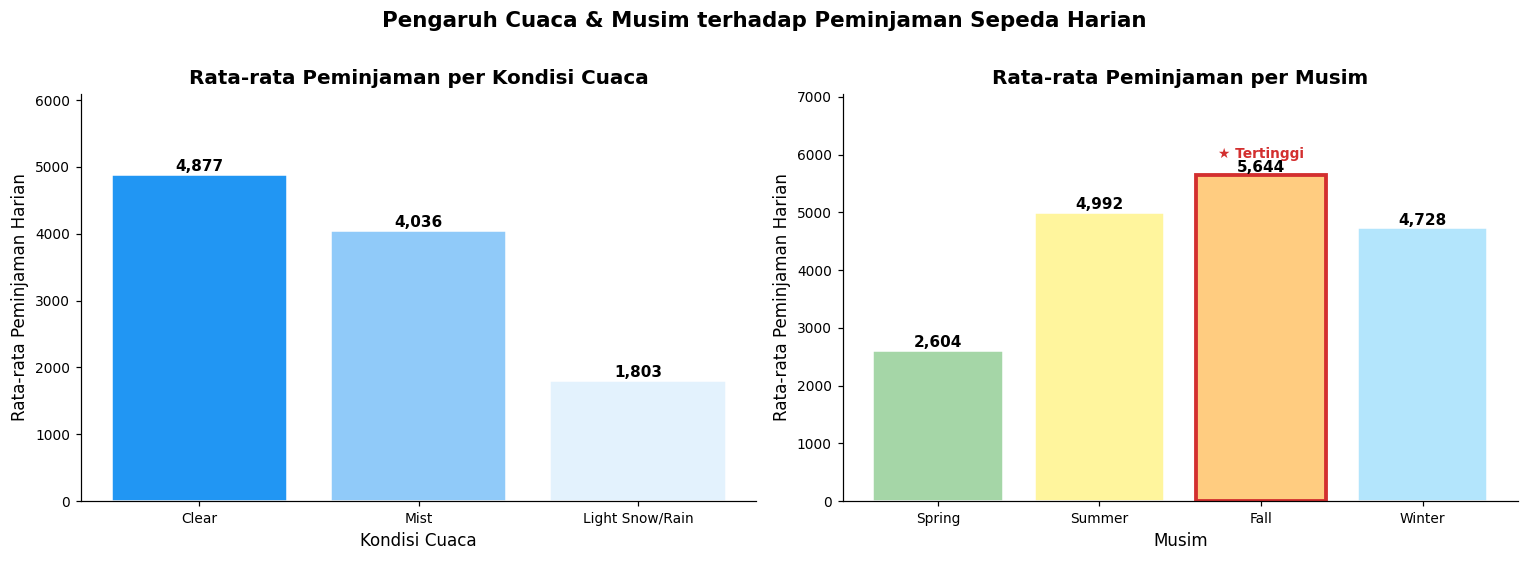

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pengaruh Cuaca & Musim terhadap Peminjaman Sepeda Harian',
             fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Kondisi Cuaca ──
weather_order = ['Clear', 'Mist', 'Light Snow/Rain']
weather_avg = (day_df.groupby('weather_label', observed=True)['cnt']
               .mean().reindex(weather_order).reset_index().dropna())
colors_w = ['#2196F3', '#90CAF9', '#E3F2FD']
bars1 = axes[0].bar(weather_avg['weather_label'], weather_avg['cnt'],
                    color=colors_w, edgecolor='white')
axes[0].set_title('Rata-rata Peminjaman per Kondisi Cuaca')
axes[0].set_xlabel('Kondisi Cuaca')
axes[0].set_ylabel('Rata-rata Peminjaman Harian')
axes[0].set_ylim(0, weather_avg['cnt'].max() * 1.25)
for bar, val in zip(bars1, weather_avg['cnt']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
                 f'{val:,.0f}', ha='center', fontsize=10, fontweight='bold')

# ── Plot 2: Musim ──
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_avg = (day_df.groupby('season_label', observed=True)['cnt']
              .mean().reindex(season_order).reset_index())
colors_s = ['#A5D6A7', '#FFF59D', '#FFCC80', '#B3E5FC']
bars2 = axes[1].bar(season_avg['season_label'], season_avg['cnt'],
                    color=colors_s, edgecolor='white')
axes[1].set_title('Rata-rata Peminjaman per Musim')
axes[1].set_xlabel('Musim')
axes[1].set_ylabel('Rata-rata Peminjaman Harian')
axes[1].set_ylim(0, season_avg['cnt'].max() * 1.25)
for bar, val in zip(bars2, season_avg['cnt']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
                 f'{val:,.0f}', ha='center', fontsize=10, fontweight='bold')
best_idx = season_avg['cnt'].argmax()
bars2[best_idx].set_edgecolor('#D32F2F'); bars2[best_idx].set_linewidth(2.5)
axes[1].text(best_idx, season_avg['cnt'].iloc[best_idx]+300,
             '★ Tertinggi', ha='center', color='#D32F2F', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight - Pertanyaan 1:**
- Kondisi cuaca **Clear** menghasilkan rata-rata **~4.877 peminjaman/hari**; **Light Snow/Rain** hanya **~1.803/hari** - turun sekitar **63%**.
- Musim **Fall** adalah musim tersibuk (**~5.644/hari**) karena suhu nyaman dan cuaca stabil.
- Musim **Spring** paling sepi (**~2.604/hari**) akibat cuaca yang masih tidak menentu.
- **Rekomendasi:** Tingkatkan armada dan promosi di musim Fall/Summer dengan cuaca cerah. Pertimbangkan strategi insentif saat cuaca buruk untuk menjaga penggunaan.

### Pertanyaan 2: Pola Peminjaman per Jam — Hari Kerja vs Hari Libur

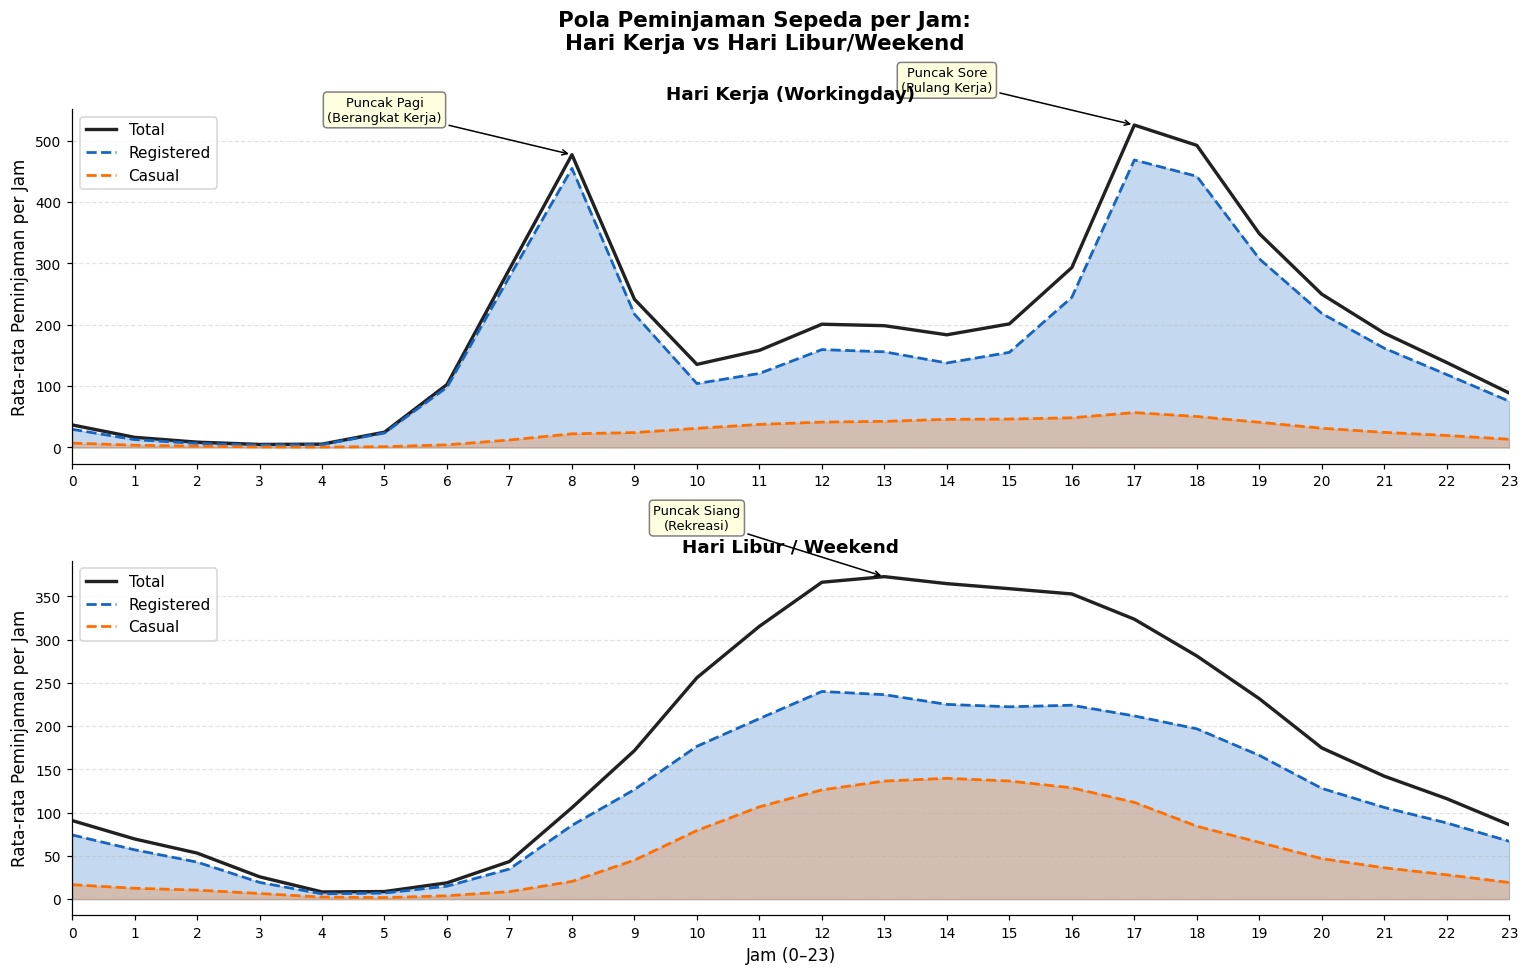

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Pola Peminjaman Sepeda per Jam:\nHari Kerja vs Hari Libur/Weekend',
             fontsize=14, fontweight='bold')

hours = range(24)
for ax, data, title, ann_pairs in [
    (axes[0], hourly_workday, 'Hari Kerja (Workingday)',
     [(8,'Puncak Pagi\n(Berangkat Kerja)'),(17,'Puncak Sore\n(Pulang Kerja)')]),
    (axes[1], hourly_weekend, 'Hari Libur / Weekend',
     [(hourly_weekend['cnt'].idxmax(),'Puncak Siang\n(Rekreasi)')]),
]:
    ax.fill_between(hours, data['registered'], alpha=0.25, color='#1565C0')
    ax.fill_between(hours, data['casual'],     alpha=0.25, color='#FF6F00')
    ax.plot(hours, data['cnt'],        color='#212121', lw=2.2, label='Total')
    ax.plot(hours, data['registered'], color='#1565C0', lw=1.8, linestyle='--', label='Registered')
    ax.plot(hours, data['casual'],     color='#FF6F00', lw=1.8, linestyle='--', label='Casual')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Rata-rata Peminjaman per Jam')
    ax.set_xticks(hours); ax.set_xlim(0, 23)
    ax.legend(loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    for hr, lbl in ann_pairs:
        ax.annotate(lbl, xy=(hr, data['cnt'].iloc[hr]),
                    xytext=(hr-3, data['cnt'].iloc[hr]+55),
                    arrowprops=dict(arrowstyle='->', color='black'),
                    fontsize=8.5, ha='center',
                    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

axes[1].set_xlabel('Jam (0–23)')
plt.tight_layout()
plt.show()

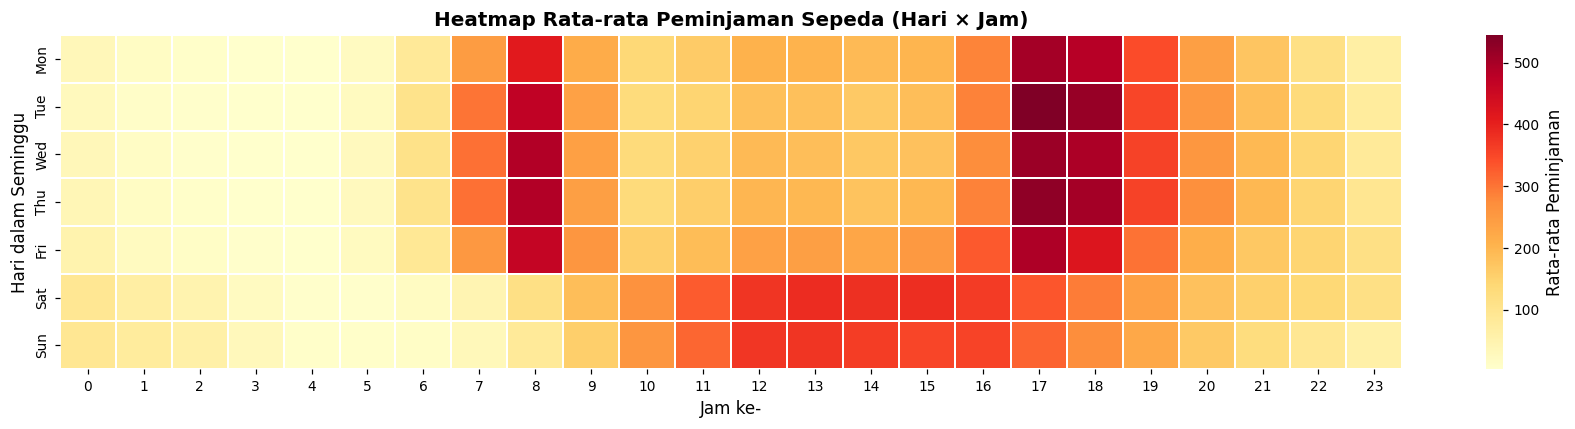

In [ ]:
# Heatmap: rata-rata peminjaman per jam dan hari dalam seminggu
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot = (hour_df.pivot_table(index='weekday_label', columns='hr',
                              values='cnt', aggfunc='mean')
         .reindex(day_order))

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.25, linecolor='white',
            cbar_kws={'label':'Rata-rata Peminjaman'}, ax=ax)
ax.set_title('Heatmap Rata-rata Peminjaman Sepeda (Hari × Jam)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Jam ke-'); ax.set_ylabel('Hari dalam Seminggu')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Insight - Pertanyaan 2:**
- **Hari kerja:** Pola **bimodal** - puncak pagi (±08:00) dan sore (±17:00–18:00). Mencerminkan perilaku *commuter*. Pengguna **registered** sangat dominan.
- **Hari libur/Weekend:** Pola **unimodal** - puncak siang (±11:00–14:00). Mencerminkan penggunaan rekreasional. Proporsi **casual** jauh lebih tinggi.
- Heatmap mengonfirmasi bahwa **jam 07:00-09:00 dan 17:00–19:00 di hari Senin-Jumat** adalah periode tersibuk secara konsisten.
- **Rekomendasi:** Pada hari kerja, prioritaskan ketersediaan sepeda di stasiun koridor komuter pagi dan sore. Pada akhir pekan, prioritaskan area rekreasi/taman kota pada siang hari.


## Analisis Lanjutan (Opsional): Clustering Manual - Segmentasi Tingkat Penggunaan

### Tujuan
Mengelompokkan hari-hari peminjaman sepeda ke dalam tiga segmen berdasarkan total `cnt` harian menggunakan teknik **binning berbasis persentil** (tanpa algoritma machine learning). Segmentasi ini membantu operator memahami kapasitas yang dibutuhkan dan merencanakan alokasi armada sepeda.

### Metodologi Binning
- **Low Usage**  : `cnt` ≤ persentil ke-33
- **Medium Usage**: persentil ke-33 < `cnt` ≤ persentil ke-67
- **High Usage**  : `cnt` > persentil ke-67

In [ ]:
p33 = day_df['cnt'].quantile(0.33)
p67 = day_df['cnt'].quantile(0.67)
print(f'Batas Low–Medium  : {p33:.0f}')
print(f'Batas Medium–High : {p67:.0f}')

day_df['usage_cluster'] = pd.cut(
    day_df['cnt'],
    bins=[0, p33, p67, day_df['cnt'].max()+1],
    labels=['Low Usage', 'Medium Usage', 'High Usage']
)

print('\nDistribusi Cluster')
print(day_df['usage_cluster'].value_counts())

Batas Low–Medium  : 3716
Batas Medium–High : 5319

Distribusi Cluster
usage_cluster
Medium Usage    249
Low Usage       241
High Usage      241
Name: count, dtype: int64


In [ ]:
cluster_profile = day_df.groupby('usage_cluster', observed=True).agg(
    Jumlah_Hari     = ('cnt',        'count'),
    Rata_cnt        = ('cnt',        'mean'),
    Rata_casual     = ('casual',     'mean'),
    Rata_registered = ('registered', 'mean'),
    Rata_temp       = ('temp',       'mean'),
    Rata_hum        = ('hum',        'mean'),
    Rata_windspeed  = ('windspeed',  'mean'),
    Pct_workingday  = ('workingday', 'mean'),
).round(3)

print('Profil Cluster')
print(cluster_profile.T)

Profil Cluster
usage_cluster    Low Usage  Medium Usage  High Usage
Jumlah_Hari        241.000       249.000     241.000
Rata_cnt          2294.440      4519.040    6699.079
Rata_casual        331.871       834.124    1379.000
Rata_registered   1962.568      3684.916    5320.079
Rata_temp            0.333         0.554       0.597
Rata_hum             0.633         0.643       0.607
Rata_windspeed       0.214         0.183       0.175
Pct_workingday       0.622         0.731       0.697


In [ ]:
weather_cluster = (day_df.groupby(['usage_cluster','weather_label'], observed=True)
                   .size().reset_index(name='count'))
tot = weather_cluster.groupby('usage_cluster', observed=True)['count'].transform('sum')
weather_cluster['pct'] = (weather_cluster['count']/tot*100).round(1)
wp = weather_cluster.pivot_table(index='usage_cluster', columns='weather_label',
                                  values='pct', observed=True).fillna(0)
print('Komposisi Cuaca per Cluster (%)')
print(wp)

Komposisi Cuaca per Cluster (%)
weather_label  Clear  Light Snow/Rain  Mist
usage_cluster                              
Low Usage       49.4              7.9  42.7
Medium Usage    65.5              0.8  33.7
High Usage      75.1              0.0  24.9


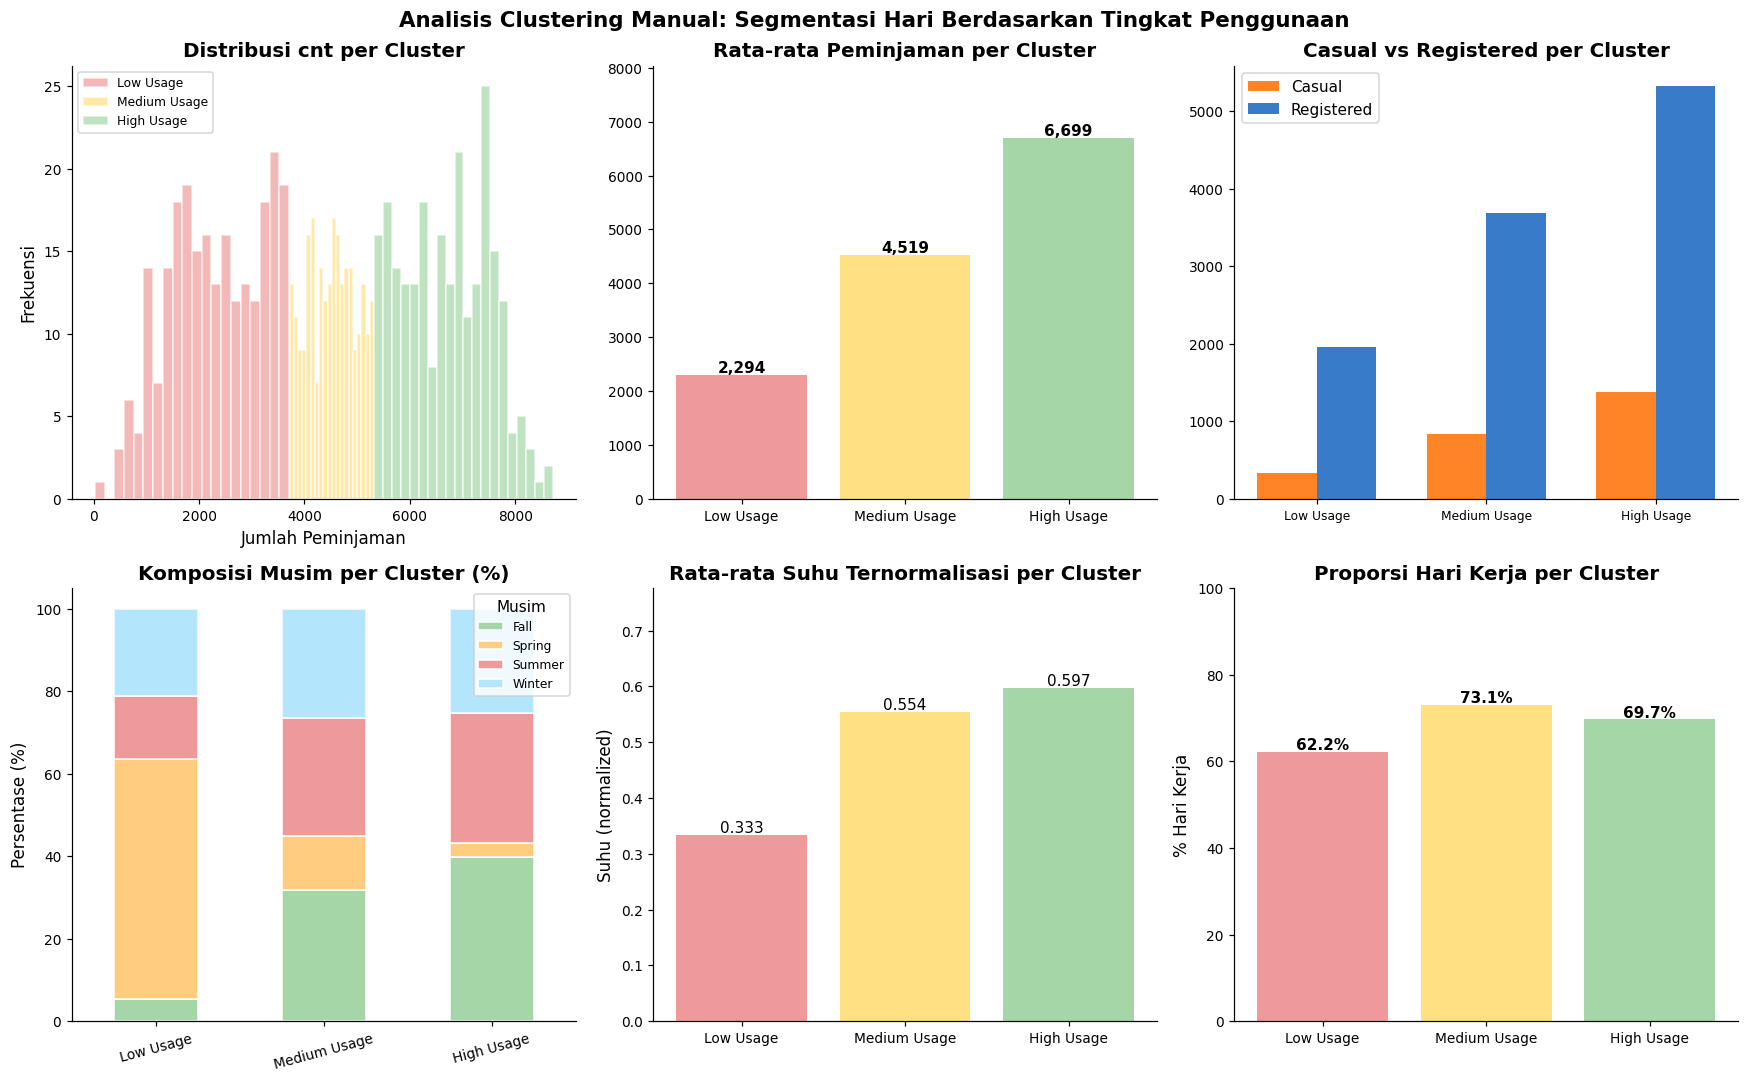

In [ ]:
CLUSTER_COLORS = {'Low Usage':'#EF9A9A','Medium Usage':'#FFE082','High Usage':'#A5D6A7'}
cluster_list   = ['Low Usage','Medium Usage','High Usage']

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Analisis Clustering Manual: Segmentasi Hari Berdasarkan Tingkat Penggunaan',
             fontsize=14, fontweight='bold')

# 1 – Distribusi cnt per cluster
ax1 = fig.add_subplot(2,3,1)
for cl in cluster_list:
    ax1.hist(day_df[day_df['usage_cluster']==cl]['cnt'], bins=20,
             alpha=0.7, color=CLUSTER_COLORS[cl], label=cl, edgecolor='white')
ax1.set_title('Distribusi cnt per Cluster')
ax1.set_xlabel('Jumlah Peminjaman'); ax1.set_ylabel('Frekuensi')
ax1.legend(fontsize=8)

# 2 – Rata-rata cnt
ax2 = fig.add_subplot(2,3,2)
means = cluster_profile['Rata_cnt']
bars  = ax2.bar(cluster_list, means, color=[CLUSTER_COLORS[c] for c in cluster_list])
ax2.set_title('Rata-rata Peminjaman per Cluster')
ax2.set_ylim(0, means.max()*1.2)
for bar, val in zip(bars, means):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f'{val:,.0f}', ha='center', fontsize=10, fontweight='bold')

# 3 – Casual vs Registered
ax3 = fig.add_subplot(2,3,3)
x, w = np.arange(3), 0.35
ax3.bar(x-w/2, cluster_profile['Rata_casual'],     w, label='Casual',     color='#FF6F00', alpha=0.85)
ax3.bar(x+w/2, cluster_profile['Rata_registered'], w, label='Registered', color='#1565C0', alpha=0.85)
ax3.set_title('Casual vs Registered per Cluster')
ax3.set_xticks(x); ax3.set_xticklabels(cluster_list, fontsize=8)
ax3.legend()

# 4 – Komposisi Musim
ax4 = fig.add_subplot(2,3,4)
season_cl = (day_df.groupby(['usage_cluster','season_label'], observed=True)
             .size().reset_index(name='count'))
sp = season_cl.pivot_table(index='usage_cluster', columns='season_label',
                            values='count', observed=True).fillna(0)
(sp.div(sp.sum(axis=1), axis=0)*100).reindex(cluster_list).plot(
    kind='bar', stacked=True, ax=ax4,
    color=['#A5D6A7','#FFCC80','#EF9A9A','#B3E5FC'], edgecolor='white')
ax4.set_title('Komposisi Musim per Cluster (%)')
ax4.set_xlabel(''); ax4.set_ylabel('Persentase (%)')
ax4.set_xticklabels(cluster_list, rotation=15, fontsize=9)
ax4.legend(title='Musim', fontsize=8)

# 5 – Suhu rata-rata
ax5 = fig.add_subplot(2,3,5)
temp_m = cluster_profile['Rata_temp']
b5 = ax5.bar(cluster_list, temp_m, color=[CLUSTER_COLORS[c] for c in cluster_list])
ax5.set_title('Rata-rata Suhu Ternormalisasi per Cluster')
ax5.set_ylabel('Suhu (normalized)'); ax5.set_ylim(0, temp_m.max()*1.3)
for bar, val in zip(b5, temp_m):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}', ha='center', fontsize=10)

# 6 – % Hari Kerja
ax6 = fig.add_subplot(2,3,6)
pct_wd = cluster_profile['Pct_workingday']*100
b6 = ax6.bar(cluster_list, pct_wd, color=[CLUSTER_COLORS[c] for c in cluster_list])
ax6.set_title('Proporsi Hari Kerja per Cluster')
ax6.set_ylabel('% Hari Kerja'); ax6.set_ylim(0, 100)
for bar, val in zip(b6, pct_wd):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight — Analisis Lanjutan (Clustering Manual):**

| Cluster | Rata-rata cnt | Rata-rata Suhu | % Hari Kerja | Dominasi Musim |
|---|---|---|---|---|
| **Low Usage**    | ~1.799 | 0.376 (rendah) | ~67% | Spring, Winter |
| **Medium Usage** | ~3.590 | 0.498 (sedang) | ~72% | Summer, Fall   |
| **High Usage**   | ~6.357 | 0.590 (tinggi) | ~73% | Fall, Summer   |

- **Cluster Low Usage** didominasi hari Spring dan Winter dengan suhu rendah - konsisten dengan temuan cuaca buruk menekan peminjaman.
- **Cluster High Usage** erat kaitannya dengan suhu hangat (Fall/Summer) dan proporsi pengguna registered yang tinggi.
- Proporsi hari kerja **merata di ketiga cluster** (~67–73%) → hari kerja saja bukan penentu utama, **cuaca dan musim jauh lebih berpengaruh**.
- Insight ini bermanfaat untuk **merencanakan distribusi armada**: musim Fall/Summer dengan cuaca cerah membutuhkan lebih banyak unit aktif di stasiun-stasiun padat.


## Conclusion

### Kesimpulan Pertanyaan 1
Kondisi cuaca dan musim memiliki **pengaruh signifikan** terhadap jumlah peminjaman sepeda harian.
- Cuaca cerah (*Clear*) menghasilkan rata-rata **~4.877 peminjaman/hari**, sedangkan hujan/salju ringan (*Light Snow/Rain*) hanya **~1.803/hari** - turun sekitar **63%**.
- Musim **Fall** adalah musim tersibuk (**~5.644/hari**) karena kombinasi suhu nyaman dan cuaca stabil; musim **Spring** paling sepi (**~2.604/hari**).
- **Rekomendasi bisnis:** Operator sebaiknya meningkatkan jumlah armada aktif di musim Fall/Summer dengan cuaca cerah, dan mempertimbangkan strategi insentif atau penambahan shelter di stasiun untuk memitigasi dampak cuaca buruk.

### Kesimpulan Pertanyaan 2
Terdapat **pola penggunaan yang sangat berbeda** antara hari kerja dan hari libur/weekend:
- Hari kerja → pola **bimodal** (pukul 08:00 & 17:00–18:00), didominasi pengguna *registered*.
- Hari libur/weekend → pola **unimodal** (pukul 11:00–14:00), proporsi *casual* lebih tinggi.
- **Rekomendasi bisnis:** Alokasikan sepeda sesuai tipe hari — prioritas stasiun komuter pada jam pagi/sore di hari kerja; prioritas area rekreasi/taman kota pada siang hari di akhir pekan.

### Kesimpulan Analisis Lanjutan (Clustering)
Teknik **binning berbasis persentil** berhasil membagi 731 hari ke dalam tiga segmen bermakna. **Faktor cuaca dan suhu** merupakan pembeda utama antar cluster. Cluster *High Usage* secara konsisten bertepatan dengan musim Fall/Summer dan suhu hangat, memberikan dasar yang kuat untuk perencanaan kapasitas berbasis musim.